In [37]:
import math 
class Value:
    def __init__(self,data, _children=() , _op='' , label=''):
        self.data=data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label
        
        
    def __repr__(self):
        return f"Value(data={self.data})"
    
    def __add__(self,other):
        other = other if isinstance(other, Value) else Value(other)
        out=Value(self.data + other.data , (self,other), '+')

    #chain rule inside add 
        def _backward():
          self.grad = 1.0 * out.grad
          other.grad = 1.0 * out.grad
        out._backward = _backward
        return out

    
    def __mul__(self,other):
        other = other if isinstance(other, Value) else Value(other)
        out=Value(self.data * other.data ,(self,other), '*')
        
#chain rule inside multiplication
        def _backward():
          self.grad = other.data * out.grad
          other.grad = self.data * out.grad
        out._backward = _backward
      
        return out

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Value(self.data**other, (self,), f'**{other}')

        def _backward():
          self.grad += other * (self.data ** (other - 1)) * out.grad
        out._backward = _backward

        return out
#https://www.mathsisfun.com/calculus/derivatives-rules.html
#check power rule 
       
    def __rmul__(self, other): # other * self
        return self * other
        
    def __truediv__(self, other): # self / other
        return self * other**-1

    def __neg__(self): # -self
        return self * -1

    def __sub__(self, other): # self - other
        return self + (-other)
       
    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t, (self, ), 'tanh')
        
#chain rule inside the tanh function 
        def _backward():
           self.grad = (1 - t**2) * out.grad
        out._backward = _backward
        
        return out

    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self, ), 'exp')
    
        def _backward():
           self.grad += out.data * out.grad # NOTE: in the video I incorrectly used = instead of +=. Fixed here.
        out._backward = _backward
    
        return out
    def backward(self):
        
        topo = []
        visited = set()
        def build_topo(v):
           if v not in visited:
             visited.add(v)
             for child in v._prev:
               build_topo(child)
               topo.append(v)
        build_topo(self)
        self.grad=1.0
        for node in reversed(topo):
               node._backward()





In [29]:
a = Value(2.0)
b = Value(4.0)
#a*3
#a._mul_(2)

#define rmul for below issue
#3 * a
#calling exp 
#a.exp()
#divide 

#a/b
#a *(1/b)
#a * ( b**=-1) #b to the power of -1 (1/b)
#x**k

a-b


Value(data=-2.0)

In [38]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})
    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        label_str = getattr(n, 'label', 'no label')
        data_val = getattr(n, 'data', 0.0)
        grad_val = getattr(n, 'grad', 0.0)
        op_str = getattr(n, '_op', '')
        dot.node(name=uid, label="{ %s | data %.4f | grad %.4f }" % (label_str, data_val, grad_val), shape='record')
        #dot.node(name=uid, label="{ %s | data %.4f  }" % (label_str, data_val), shape='record')
        if op_str:
            dot.node(name=uid + op_str, label=op_str)
            dot.edge(uid + op_str, uid)
    for n1, n2 in edges:
        op_str = getattr(n2, '_op', '')
        dot.edge(str(id(n1)), str(id(n2)) + op_str)
    return dot
    


In [30]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'
o.backward()

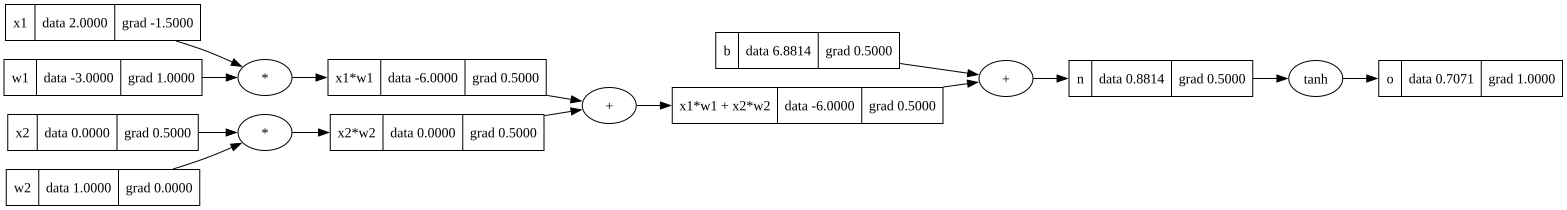

In [31]:
draw_dot(o)

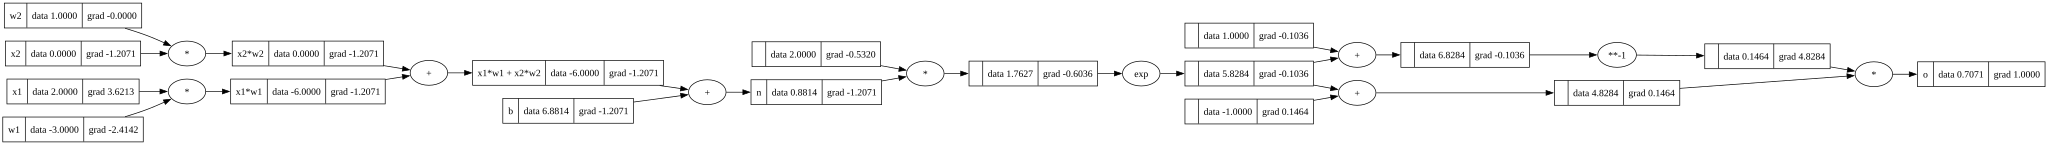

In [39]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
#------------
#o = n.tanh();
#https://sl.bing.net/hwxluVwV9ky
#expcet long graph
#same backward pass 

e = (2*n).exp()
o = (e - 1) / (e + 1)
#-------------
o.label = 'o'
o.backward()
draw_dot(o)

In [46]:
#implement pytorch 

import torch

In [50]:
x = torch.tensor([[1, 2, 3], [4, 5, 6]])
print(x)


tensor([[1, 2, 3],
        [4, 5, 6]])


In [51]:
torch.Tensor([2.0]).double().dtype

torch.float64

In [52]:
x1 = torch.Tensor([2.0]).double()                ; x1.requires_grad = True
x2 = torch.Tensor([0.0]).double()                ; x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double()               ; w1.requires_grad = True
w2 = torch.Tensor([1.0]).double()                ; w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double()  ; b.requires_grad = True
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('---')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

0.7071066904050358
---
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


In [54]:
o.item()

0.7071066904050358

In [55]:
x2.grad.item()

0.5000001283844369